In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('../datasets/Crop_recommendation.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (2200, 8)

Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [5]:
print("Total duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

Total duplicate rows: 0
After removing duplicates: (2200, 8)


In [6]:
print(df.dtypes)

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object


In [7]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [8]:
print("Total unique crops:", df['label'].nunique())
print("\nCrop names:")
print(df['label'].unique())

Total unique crops: 22

Crop names:
<StringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str


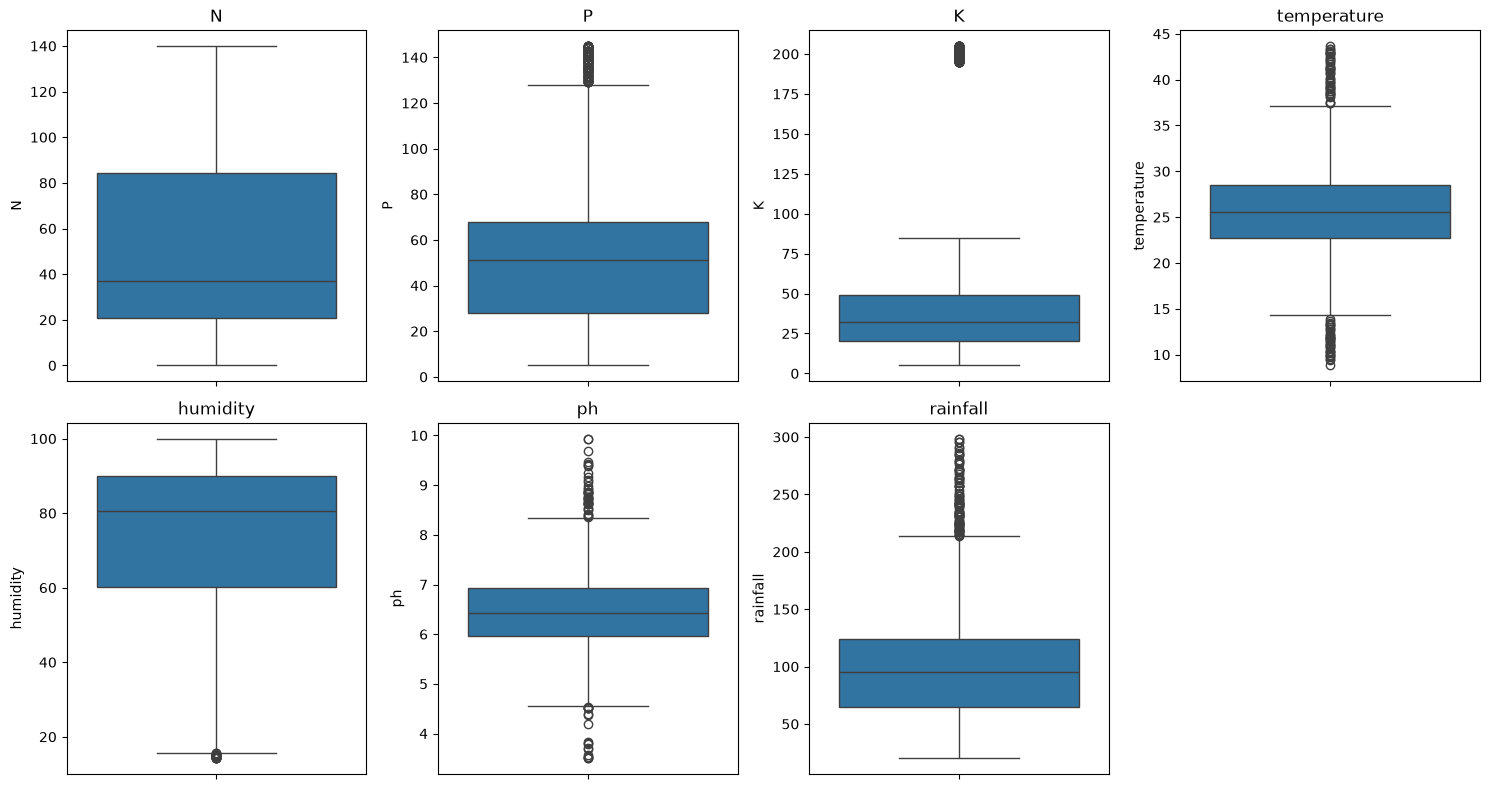

In [9]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

plt.figure(figsize=(15, 8))
for i, col in enumerate(features):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [10]:
# Remove physically impossible values
df = df[df['ph'].between(0, 14)]
df = df[df['temperature'].between(0, 60)]
df = df[df['humidity'].between(0, 100)]
df = df[df['rainfall'] >= 0]
df = df[df['N'] >= 0]
df = df[df['P'] >= 0]
df = df[df['K'] >= 0]

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (2200, 8)


In [12]:
from sklearn.preprocessing import LabelEncoder
import pickle

le_crop = LabelEncoder()
df['crop_encoded'] = le_crop.fit_transform(df['label'])

print("Crop encoding mapping:")
for i, crop in enumerate(le_crop.classes_):
    print(f"  {crop} → {i}")

# Save encoder
pickle.dump(le_crop, open('../models/crop_encoder.pkl', 'wb'))
print("\nCrop encoder saved!")

Crop encoding mapping:
  apple → 0
  banana → 1
  blackgram → 2
  chickpea → 3
  coconut → 4
  coffee → 5
  cotton → 6
  grapes → 7
  jute → 8
  kidneybeans → 9
  lentil → 10
  maize → 11
  mango → 12
  mothbeans → 13
  mungbean → 14
  muskmelon → 15
  orange → 16
  papaya → 17
  pigeonpeas → 18
  pomegranate → 19
  rice → 20
  watermelon → 21

Crop encoder saved!


In [13]:
df.to_csv('../datasets/cleaned_crop.csv', index=False)
print("Cleaned crop dataset saved!")
print("Final shape:", df.shape)
df.head()

Cleaned crop dataset saved!
Final shape: (2200, 9)


,N,P,K,temperature,humidity,ph,rainfall,label,crop_encoded
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,20


In [14]:
verify = pd.read_csv('../datasets/cleaned_crop.csv')
print("Verified saved file shape:", verify.shape)
print("Columns:", verify.columns.tolist())

Verified saved file shape: (2200, 9)
Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label', 'crop_encoded']


In [15]:
verify = pd.read_csv('../datasets/cleaned_crop.csv')
print("Verified saved file shape:", verify.shape)
print("Columns:", verify.columns.tolist())

Verified saved file shape: (2200, 9)
Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label', 'crop_encoded']
